In [2]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# =========================================================
# Load + prepare data
# =========================================================
data = pd.read_csv("C:/Users/aiden/School/6380/in-silico-drug-discovery/data/input_data.csv")

labeled = data[data["senolytic"].isin([0, 1])].copy()

X = labeled.drop(columns=["senolytic", "ID", "SMILES"])
y = labeled["senolytic"].values
X.shape

(4866, 200)

In [3]:
# CPU Parallelism for speed

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix
)

from joblib import Parallel, delayed
import multiprocessing

# --------------------------------------------------
# Single fold function (THIS gets parallelized)
# --------------------------------------------------
def process_fold(train_idx, test_idx, X, y):

    X_train = X.iloc[train_idx].values
    X_test = X.iloc[test_idx].values

    y_train = y[train_idx]
    y_test = y[test_idx]

    # ----------------------------------------
    # Variance filter
    # ----------------------------------------
    variances = np.var(X_train, axis=0)
    keep_var = variances > 1e-6

    X_train = X_train[:, keep_var]
    X_test = X_test[:, keep_var]

    # ----------------------------------------
    # Scaling
    # ----------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ----------------------------------------
    # PCA (for distance only)
    # ----------------------------------------
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # ----------------------------------------
    # KNN neighborhood
    # ----------------------------------------
    k = 50
    knn = NearestNeighbors(n_neighbors=k, metric="cosine")
    knn.fit(X_train_pca)

    distances, indices = knn.kneighbors(X_test_pca)

    neighbor_idx = indices[0]
    dists = distances[0]

    X_neighbors = X_train_scaled[neighbor_idx]
    y_neighbors = y_train[neighbor_idx]

    pos_count = np.sum(y_neighbors == 1)
    neg_count = np.sum(y_neighbors == 0)

    # ----------------------------------------
    # Distance weights
    # ----------------------------------------
    sigma = np.mean(dists) + 1e-8
    weights = np.exp(-(dists**2) / (2 * sigma**2))

    if np.sum(weights) == 0:
        weights = np.ones_like(weights)
        
    # ----------------------------------------
    # Fallback logic
    # ----------------------------------------
    if pos_count == 1 and neg_count > 2:
        prob = 0.02
    elif neg_count == 1 and pos_count > 2:
        prob = 0.98
    elif pos_count == 0:
        prob = 0.001
    elif neg_count == 0:
        prob = .999
    else:
        ratio = neg_count / (pos_count + 1e-8)

        if ratio >= 1:
            w_pos = min(.65 * ratio, 4)
            w_neg = 1.0
        else:
            inv_ratio = 1 / (ratio + 1e-8)
            w_neg = min(inv_ratio, 1.1)
            w_pos = 1.0
             
        scale = (w_pos + w_neg) / 2
        w_pos /= scale
        w_neg /= scale

        sample_weights = weights.copy()
        sample_weights[y_neighbors == 1] *= w_pos
        sample_weights[y_neighbors == 0] *= w_neg

        # ----------------------------------------
        # Model
        # ----------------------------------------
        model = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000
        )

        model.fit(X_neighbors, y_neighbors, sample_weight=sample_weights)

        # ----------------------------------------
        #  ORIGINAL PREDICTION
        # ----------------------------------------
        prob = model.predict_proba(X_test_scaled)[0, 1]

        # ----------------------------------------
        #  adjusting predictions based on clusters confidence
        # ----------------------------------------
        neighbor_preds = model.predict(X_neighbors)


        # distance-weighted confidence (stronger signal)
        confidence = np.average(
            (neighbor_preds == y_neighbors).astype(float),
            weights=weights
        )

        # Boost / dampen
        if confidence > 0.95 and prob > 0.35 and prob < .51:
            prob = .51
        

    pred = int(prob >= 0.5)

    return {
        "true": y_test[0],
        "pred": pred,
        "prob": prob
    }


# --------------------------------------------------
# Parallel LOOCV runner
# --------------------------------------------------
def run_loocv_parallel(X, y, n_jobs=-1):

    loo = LeaveOneOut()
    splits = list(loo.split(X, y))

    print(f"Running LOOCV with {len(splits)} folds...")
    print(f"Using {multiprocessing.cpu_count()} CPU cores")

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_fold)(train_idx, test_idx, X, y)
        for train_idx, test_idx in splits
    )

    df_results = pd.DataFrame(results)

    y_true = df_results["true"].values
    y_pred = df_results["pred"].values
    y_prob = df_results["prob"].values

    print("\n==============================")
    print("LOOCV RESULTS (PARALLEL)")
    print("==============================")
    print("AUC:", roc_auc_score(y_true, y_prob))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

    return df_results


# --------------------------------------------------
# Run it
# --------------------------------------------------
loocv_df = run_loocv_parallel(X, y, n_jobs=-1)

Running LOOCV with 4866 folds...
Using 16 CPU cores


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  


LOOCV RESULTS (PARALLEL)
AUC: 0.803233460187652
Precision: 0.49206349206349204
Recall: 0.30097087378640774
F1: 0.37349397590361444
Accuracy: 0.9786272092067406

Confusion Matrix:
 [[4731   32]
 [  72   31]]


[Parallel(n_jobs=-1)]: Done 4866 out of 4866 | elapsed:   54.8s finished


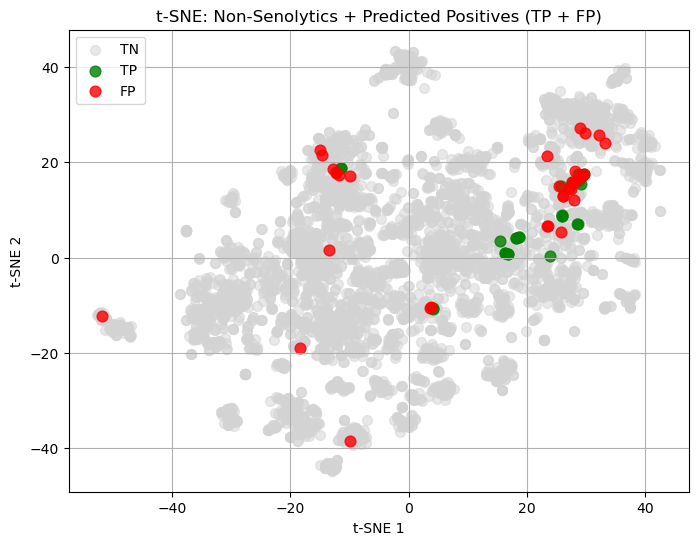

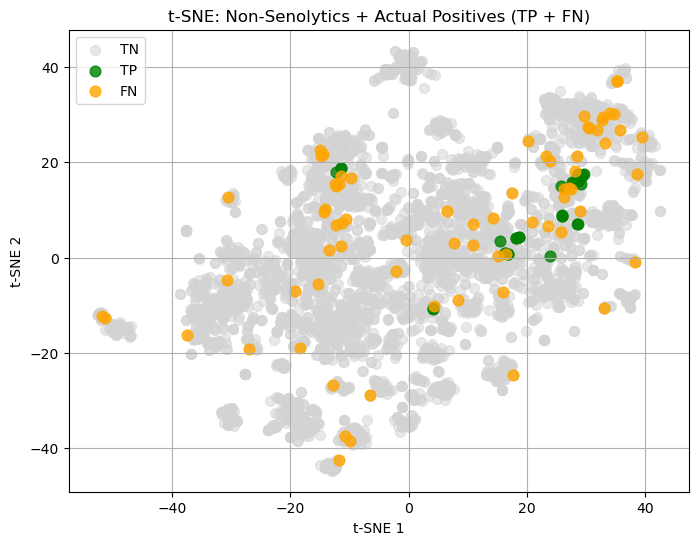

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
# 1️⃣ Impute missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X.values)  # X is your features DataFrame

# 2️⃣ Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3️⃣ Optional: Check for NaNs / Infs
if np.any(np.isnan(X_scaled)) or np.any(np.isinf(X_scaled)):
    raise ValueError("Data contains NaNs or Infs after scaling!")

# 4️⃣ Compute t-SNE
tsne = TSNE(n_components=2, metric="cosine", perplexity=100, max_iter=1000, init='pca')
X_tsne = tsne.fit_transform(X_scaled)  # This is the array your plots will use

# Map outcomes
outcome = np.array([
    "TP" if t==1 and p==1 else
    "TN" if t==0 and p==0 else
    "FN" if t==1 and p==0 else
    "FP" for t,p in zip(loocv_df["true"], loocv_df["pred"])
])

# Get indices
neg_idx = np.where(outcome == "TN")[0]
tp_idx  = np.where(outcome == "TP")[0]
fp_idx  = np.where(outcome == "FP")[0]
fn_idx  = np.where(outcome == "FN")[0]

# -----------------------
# Plot 1: Negatives + Predicted Positives (TP + FP)
# -----------------------
plt.figure(figsize=(8,6))
# Background negatives
plt.scatter(X_tsne[neg_idx,0], X_tsne[neg_idx,1], c="lightgrey", label="TN", alpha=0.5, s=50)
# Predicted positives
plt.scatter(X_tsne[tp_idx,0], X_tsne[tp_idx,1], c="green", label="TP", alpha=0.8, s=60)
plt.scatter(X_tsne[fp_idx,0], X_tsne[fp_idx,1], c="red", label="FP", alpha=0.8, s=60)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE: Non-Senolytics + Predicted Positives (TP + FP)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------
# Plot 2: Negatives + Actual Positives (TP + FN)
# -----------------------
plt.figure(figsize=(8,6))
# Background negatives
plt.scatter(X_tsne[neg_idx,0], X_tsne[neg_idx,1], c="lightgrey", label="TN", alpha=0.5, s=50)
# Actual positives
plt.scatter(X_tsne[tp_idx,0], X_tsne[tp_idx,1], c="green", label="TP", alpha=0.8, s=60)
plt.scatter(X_tsne[fn_idx,0], X_tsne[fn_idx,1], c="orange", label="FN", alpha=0.8, s=60)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE: Non-Senolytics + Actual Positives (TP + FN)")
plt.legend()
plt.grid(True)
plt.show()

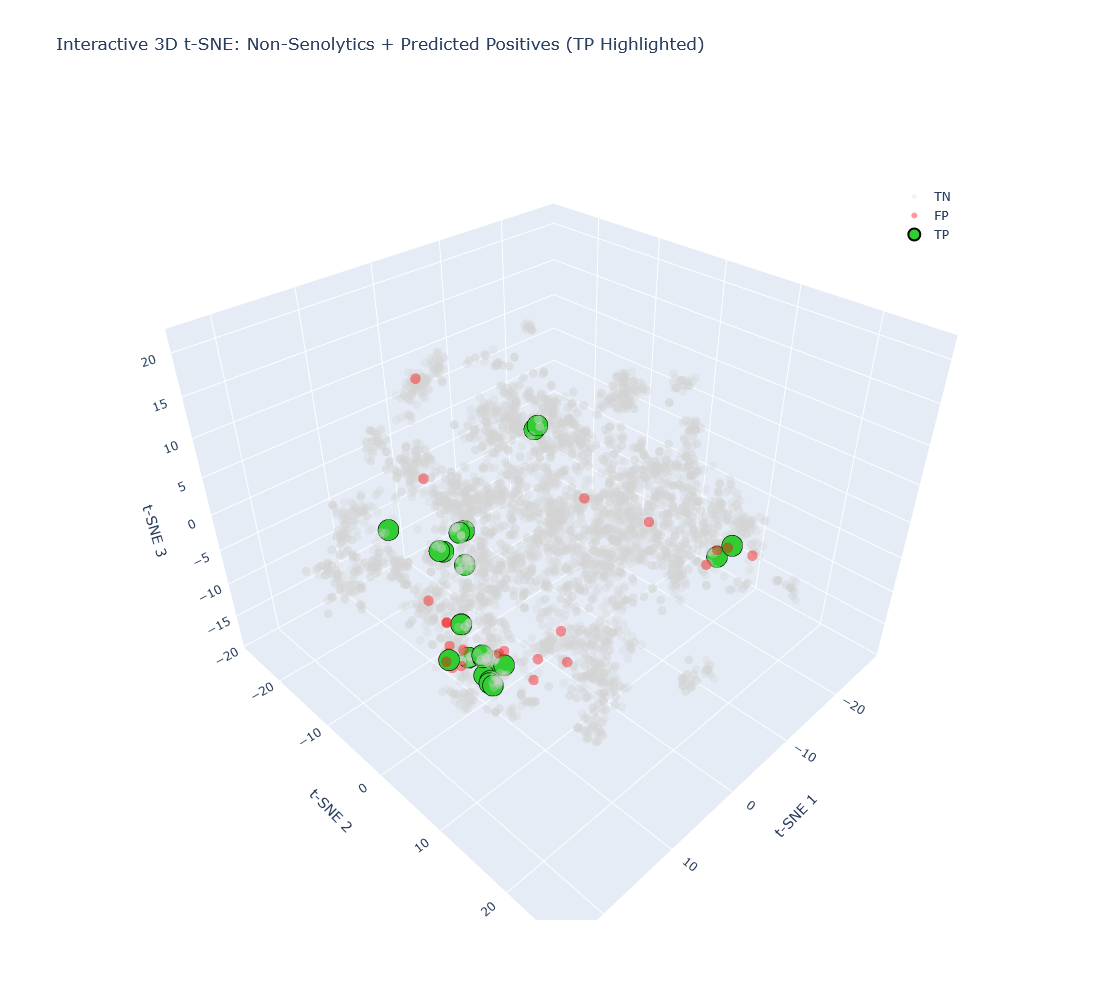

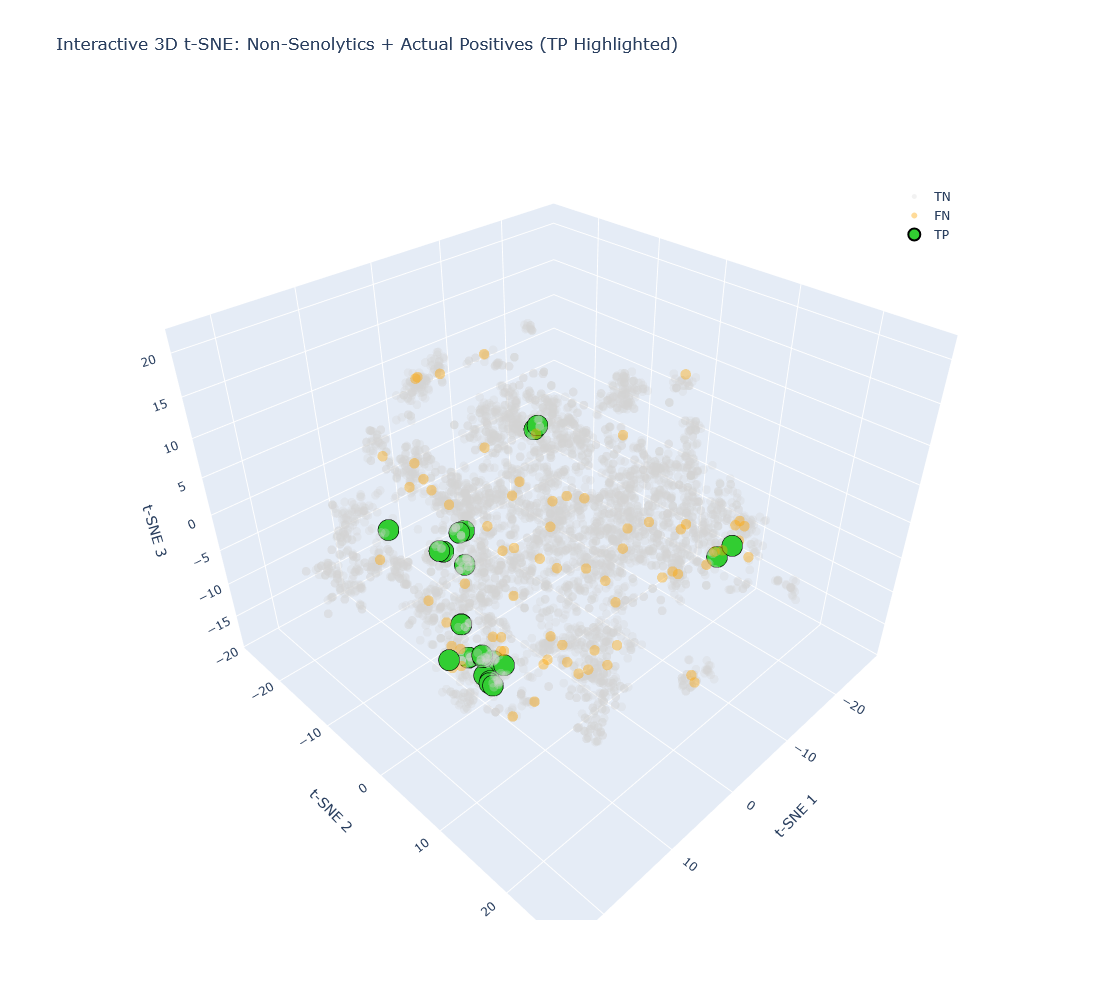

In [8]:
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
import numpy as np

# 1️⃣ Impute missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X.values)

# 2️⃣ Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3️⃣ Check for NaNs / Infs
if np.any(np.isnan(X_scaled)) or np.any(np.isinf(X_scaled)):
    raise ValueError("Data contains NaNs or Infs after scaling!")

# 4️⃣ Compute t-SNE in 3D
tsne = TSNE(n_components=3, metric="cosine", perplexity=50, max_iter=1000, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Map outcomes
outcome = np.array([
    "TP" if t==1 and p==1 else
    "TN" if t==0 and p==0 else
    "FN" if t==1 and p==0 else
    "FP" for t,p in zip(loocv_df["true"], loocv_df["pred"])
])

# Get indices
neg_idx = np.where(outcome == "TN")[0]
tp_idx  = np.where(outcome == "TP")[0]
fp_idx  = np.where(outcome == "FP")[0]
fn_idx  = np.where(outcome == "FN")[0]

# -----------------------
# Interactive 3D Plot: Negatives + Predicted Positives (TP + FP)
# -----------------------
fig = go.Figure()

# Background negatives (faded)
fig.add_trace(go.Scatter3d(
    x=X_tsne[neg_idx,0], y=X_tsne[neg_idx,1], z=X_tsne[neg_idx,2],
    mode='markers',
    name='TN',
    marker=dict(size=5, color='lightgrey', opacity=0.3)
))

# Predicted FP (faded)
fig.add_trace(go.Scatter3d(
    x=X_tsne[fp_idx,0], y=X_tsne[fp_idx,1], z=X_tsne[fp_idx,2],
    mode='markers',
    name='FP',
    marker=dict(size=6, color='red', opacity=0.4)
))

# Predicted TP (highlighted)
fig.add_trace(go.Scatter3d(
    x=X_tsne[tp_idx,0], y=X_tsne[tp_idx,1], z=X_tsne[tp_idx,2],
    mode='markers',
    name='TP',
    marker=dict(size=12, color='limegreen', opacity=1.0, line=dict(color='black', width=2))
))

fig.update_layout(
    width=1400,
    height=1000,
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3'
    ),
    title="Interactive 3D t-SNE: Non-Senolytics + Predicted Positives (TP Highlighted)",
    legend=dict(x=0.85, y=0.9)
)

fig.show()

# -----------------------
# Interactive 3D Plot: Negatives + Actual Positives (TP + FN)
# -----------------------
fig2 = go.Figure()

# Background negatives (faded)
fig2.add_trace(go.Scatter3d(
    x=X_tsne[neg_idx,0], y=X_tsne[neg_idx,1], z=X_tsne[neg_idx,2],
    mode='markers',
    name='TN',
    marker=dict(size=5, color='lightgrey', opacity=0.3)
))

# Actual FN (faded)
fig2.add_trace(go.Scatter3d(
    x=X_tsne[fn_idx,0], y=X_tsne[fn_idx,1], z=X_tsne[fn_idx,2],
    mode='markers',
    name='FN',
    marker=dict(size=6, color='orange', opacity=0.4)
))

# Actual TP (highlighted)
fig2.add_trace(go.Scatter3d(
    x=X_tsne[tp_idx,0], y=X_tsne[tp_idx,1], z=X_tsne[tp_idx,2],
    mode='markers',
    name='TP',
    marker=dict(size=12, color='limegreen', opacity=1.0, line=dict(color='black', width=2))
))

fig2.update_layout(
    width=1400,
    height=1000,
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3'
    ),
    title="Interactive 3D t-SNE: Non-Senolytics + Actual Positives (TP Highlighted)",
    legend=dict(x=0.85, y=0.9)
)

fig2.show()